## Análise inicial do dataset

### Importação de bibliotecas

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import stanza

plt.style.use('ggplot')

from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import re
import nltk

try:
    nltk.download('punkt', quiet=True)
    nltk.download('punkt_tab', quiet=True)
    nltk.download('stopwords', quiet=True)
    nltk.download('wordnet', quiet=True)
    print("Downloads concluídos com sucesso.")
except Exception as e:
    print(f"Erro no download: {e}")


Downloads concluídos com sucesso.


### Carregar dados do dataset (treino e teste)

In [4]:
df_test = pd.read_csv("../src/Tweets_EN_sentiment_test.csv")
df_train = pd.read_csv("../src/Tweets_EN_sentiment_train.csv")

print("Informação do dataset:")
print(df_test.info())

Informação do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2122 entries, 0 to 2121
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   tweet   2122 non-null   int64 
 1   text    2100 non-null   object
 2   class   2122 non-null   object
dtypes: int64(1), object(2)
memory usage: 49.9+ KB
None


Criação de um set com stopwords que não queremos retirar do dataset, já que providenciam informação importante para a aplicação de modelos que têm em conta palavras de negação para inverter o sinal do que se segue (_NOT)

In [5]:
stopwords = nltk.corpus.stopwords.words('english')
print("total words:", len(stopwords))
print(stopwords)

palavras_negacao = {
    "not", "no", "nor", "never", "none", "nothing", "nowhere", "nobody", "against", "cannot",
    "don't", "dont", "aren't", "arent", "couldn't", "couldnt", "didn't", "didnt", "doesn't", "doesnt",
    "hadn't", "hadnt", "hasn't", "hasnt", "haven't", "havent", "isn't", "isnt", "mightn't", "mightnt",
    "mustn't", "mustnt", "needn't", "neednt", "shan't", "shant", "shouldn't", "shouldnt", "wasn't",
    "wasnt", "weren't", "werent", "won't", "wont", "wouldn't", "wouldnt", "can't", "cant"
}

stopwords_clean = [word for word in stopwords if word not in palavras_negacao]
print(stopwords_clean)


total words: 198
['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan

Remover URLs e menções (@utilizador) através de expressões regulares (Regex), pois não contêm valor de sentimento.

Filtrar caracteres não alfanuméricos, mantendo a pontuação expressiva como exclamações e emojis.

Preservar a capitalização (palavras em MAIÚSCULAS), dado que intensificam a polaridade nas métricas.

Filtrar stop words, garantindo que negações cruciais como "not" ou "no" são mantidas para não destruir o contexto.

Aplicar lematização para reduzir as palavras à sua forma base, facilitando o cruzamento com o dicionário do léxico.

STANZA - ele considera alguns stopwords relevantes como "but" etc. Não retirar.
VADER - consegue ler emojis #utilizando a biblioteca emoji para transformar "I love this 😭" em "I love this :loudly_crying_face:"
TextBlob - não diferencia maiúsculas de minúsculas no seu cálculo de polaridade, mas o VADER usa isso como um multiplicador.

Se o seu dataset for desequilibrado (por exemplo, se 80% dos tweets totais forem positivos), estabelece-se a regra de que qualquer empate ou falta de sinal (zero) é classificado automaticamente como "pos". É uma heurística de negócio utilizada para maximizar a probabilidade estatística de acerto quando o algoritmo falha.

### Análise da distribuição do dataset (conjunto de teste)

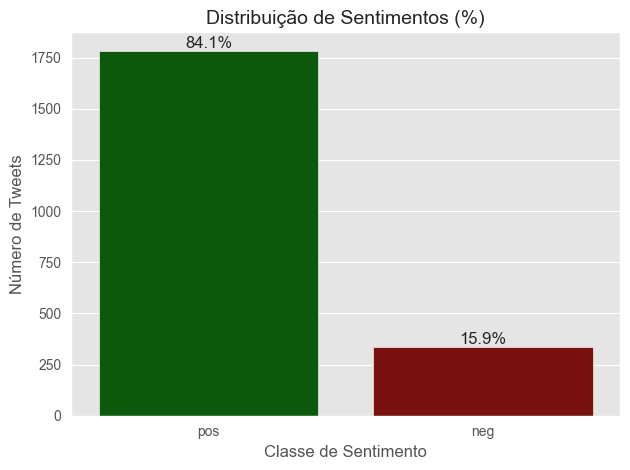

In [6]:
cores = {'pos': 'darkgreen', 'neg': 'darkred'}

ax = sns.countplot(data=df_test, x='class', hue='class', palette=cores, legend=False)

total = len(df_test['class'])

for p in ax.patches:
    percentagem = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentagem, (x, y), ha='center', va='bottom', fontsize=12)

plt.title('Distribuição de Sentimentos (%)', fontsize=14)
plt.xlabel('Classe de Sentimento', fontsize=12)
plt.ylabel('Número de Tweets', fontsize=12)
plt.tight_layout()
plt.show()

É deveras desequilibrado :)

Por isso vamos aplicar as seguintes regras -
VADER e TextBlob, Qualquer score contínuo de $0.0$ (neutro) é automaticamente classificado como "pos"
Stanza, Qualquer média de $1.0$ (neutro na escala Stanford) ou falha na leitura (texto vazio) é automaticamente absorvida pela classe "pos"

Cenários de limpeza distintos

Cenário A (Baseline), Limpeza segura que mantém pontuação expressiva, números, capitalização e remove apenas as stopwords irrelevantes.

Cenário B (Sem Números), Retira puramente os dígitos para testar o nível de ruído provocado por gírias e classificações numéricas.

Cenário C (Full Context), Não remove nenhuma stopword, preservando a sintaxe absoluta da frase para testar se os modelos neurais (Stanza) beneficiam da gramática completa.

## Pré-processamento inicial

In [7]:
lemmatizer = WordNetLemmatizer()

def limpar_texto_base(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r'http\S+|www.\S+', '', text)
    text = re.sub(r'\bUSER\b', '', text)
    text = re.sub(r'\bURL\b', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'^\s*RT\s+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'[^\w\s\?\!\']', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def processar_tokens(text, remove_stopwords=True, remove_numbers=False, full_context=False, use_lemmatization=True):
    if not isinstance(text, str):
        return ""
    text = limpar_texto_base(text)
    if not text:
        return ""
    tokens = word_tokenize(text)
    tokens_limpos = []
    for w in tokens:
        if w in {'!', '?'}:
            tokens_limpos.append(w)
            continue
        if remove_numbers and re.fullmatch(r'\d+([.,:/-]\d+)*', w):
            continue
        if not re.search(r"[A-Za-z0-9#']", w):
            continue
        base = w
        if not base:
            continue
        if not full_context and remove_stopwords and base.lower() in stopwords_clean:
            continue
        if use_lemmatization:
            token_final = lemmatizer.lemmatize(base.lower())
        else:
            token_final = base.lower()
        if base.isupper() and len(base) > 1:
            token_final = token_final.upper()
        tokens_limpos.append(token_final)
    return ' '.join(tokens_limpos)

In [8]:
# Cenário A
def prep_baseline(text):
    if not isinstance(text, str):
        return ""
    return processar_tokens(
        text,
        remove_stopwords=True,
        remove_numbers=False,
        full_context=False,
        use_lemmatization=True
    )

# Cenário B
def prep_full_context(text):
    if not isinstance(text, str):
        return ""
    return processar_tokens(
        text,
        remove_stopwords=False,
        remove_numbers=False,
        full_context=True,
        use_lemmatization=True
    )


# Cenário C - sem lematização
def prep_sem_lematizacao(text):
    if not isinstance(text, str):
        return ""
    return processar_tokens(
        text,
        remove_stopwords=True,
        remove_numbers=False,
        full_context=False,
        use_lemmatization=False
    )

df_test['text_baseline'] = df_test['text'].apply(prep_baseline)
df_test['text_full_context'] = df_test['text'].apply(prep_full_context)
df_test['text_sem_lematizacao'] = df_test['text'].apply(prep_sem_lematizacao)

print("Cenários processados com sucesso.")

Cenários processados com sucesso.


In [9]:
# Ver alguns exemplos do pré-processamento
df_test[['text', 'text_baseline', 'text_full_context', 'text_sem_lematizacao']].head(10)

,text,text_baseline,text_full_context,text_sem_lematizacao
0,lmao i love it.,lmao love,lmao i love it,lmao love
1,"Never been to Australia, but I'll keep that in...",never australia 'll keep mind eat mcdonald 's ...,never been to australia but i 'll keep that in...,never australia 'll keep mind eat mcdonald 's ...
2,Tired as shit...but what else is new...and don...,tired shitbut else newand n't want go work day...,tired a shitbut what else is newand do n't wan...,tired shitbut else newand n't want go work day...
3,Levi's!,levi 's !,levi 's !,levi 's !
4,"no sweetie, its not love, probably just heart ...",no sweetie not love probably heart burn get tw...,no sweetie it not love probably just heart bur...,no sweetie not love probably heart burn get tw...
5,"I am eating chocolate chips, pecans and peanut...",eating chocolate chip pecan peanut butter jar ...,i am eating chocolate chip pecan and peanut bu...,eating chocolate chips pecans peanut butter ja...
6,"Yes, that frank lloyd wright house, a man has ...",yes frank lloyd wright house man goal know,yes that frank lloyd wright house a man ha to ...,yes frank lloyd wright house man goals know
7,"Yeah, pretty much...",yeah pretty much,yeah pretty much,yeah pretty much
8,"ben gaar, ook nog zakelijk diner vanavond. eve...",ben gaar ook nog zakelijk diner vanavond even ...,ben gaar ook nog zakelijk diner vanavond even ...,ben gaar ook nog zakelijk diner vanavond even ...
9,"My photoshop skills lag, but I can assure you ...",photoshop skill lag assure cabo cloudy today h...,my photoshop skill lag but i can assure you ca...,photoshop skills lag assure cabo cloudy today ...


In [10]:
# Inicializar modelos
analyzer_vader = SentimentIntensityAnalyzer()

# Download Stanza model (só precisa fazer uma vez)
# stanza.download('en')
nlp_stanza = stanza.Pipeline('en', processors='tokenize,sentiment', verbose=False)


def classificar_textblob(text):
    if not isinstance(text, str) or text.strip() == '':
        return 'pos'
    polarity = TextBlob(text).sentiment.polarity
    return 'pos' if polarity >= 0 else 'neg'


def classificar_vader(text):
    if not isinstance(text, str) or text.strip() == '':
        return 'pos'
    scores = analyzer_vader.polarity_scores(text)
    compound = scores['compound']
    return 'pos' if compound >= 0.0 else 'neg'

In [11]:
_stanza_cache = {}

def classificar_stanza(textos, batch_size=64):
    resultados = [None] * len(textos)
    indices_novos = []
    textos_novos  = []
    for i, t in enumerate(textos):
        t_safe = t if (isinstance(t, str) and t.strip()) else 'neutral text'
        if t_safe in _stanza_cache:
            resultados[i] = _stanza_cache[t_safe]
        else:
            indices_novos.append(i)
            textos_novos.append(t_safe)
    for batch_start in range(0, len(textos_novos), batch_size):
        batch = textos_novos[batch_start:batch_start + batch_size]
        try:
            # Stanza aceita lista de documentos em modo batch
            docs = [stanza.Document([], text=t) for t in batch]
            docs_proc = nlp_stanza(docs)
            for j, doc in enumerate(docs_proc):
                sents = [s.sentiment for s in doc.sentences]
                media = np.mean(sents) if sents else 1.0
                label = 'pos' if media >= 1.0 else 'neg'
                t_key = textos_novos[batch_start + j]
                _stanza_cache[t_key] = label
                resultados[indices_novos[batch_start + j]] = label
        except Exception:
            # fallback individual se o batch falhar
            for j, t in enumerate(batch):
                try:
                    doc   = nlp_stanza(t)
                    sents = [s.sentiment for s in doc.sentences]
                    label = 'pos' if (np.mean(sents) if sents else 1.0) >= 1.0 else 'neg'
                except Exception:
                    label = 'pos'
                _stanza_cache[t] = label
                resultados[indices_novos[batch_start + j]] = label

    return resultados

In [12]:
## 5. Aplicar Modelos aos 3 Cenários

In [13]:
cenarios = {
    'text_baseline':        'Baseline',
    'text_full_context':    'Full Context',
    'text_sem_lematizacao': 'Sem Lematização',
}

for col in cenarios:
    df_test[f'{col}_pred_textblob'] = df_test[col].apply(classificar_textblob)
    df_test[f'{col}_pred_vader']    = df_test[col].apply(classificar_vader)

for col in cenarios.keys():
    df_test[f'{col}_pred_stanza'] = classificar_stanza(
        df_test[col].tolist(), batch_size=64
    )

In [14]:
# Ver alguns exemplos
df_test[['text', 'class',
         'text_baseline_pred_textblob',
         'text_baseline_pred_vader',
         'text_baseline_pred_stanza',
         'text_sem_lematizacao_pred_textblob',
         'text_sem_lematizacao_pred_vader',
         'text_sem_lematizacao_pred_stanza']].head(10)

,text,class,text_baseline_pred_textblob,text_baseline_pred_vader,text_baseline_pred_stanza,text_sem_lematizacao_pred_textblob,text_sem_lematizacao_pred_vader,text_sem_lematizacao_pred_stanza
0,lmao i love it.,pos,pos,pos,pos,pos,pos,pos
1,"Never been to Australia, but I'll keep that in...",pos,pos,pos,pos,pos,pos,pos
2,Tired as shit...but what else is new...and don...,neg,neg,neg,neg,neg,neg,neg
3,Levi's!,pos,pos,pos,pos,pos,pos,pos
4,"no sweetie, its not love, probably just heart ...",pos,pos,neg,pos,pos,neg,pos
5,"I am eating chocolate chips, pecans and peanut...",pos,neg,neg,neg,neg,neg,neg
6,"Yes, that frank lloyd wright house, a man has ...",pos,pos,pos,pos,pos,pos,pos
7,"Yeah, pretty much...",pos,pos,pos,pos,pos,pos,pos
8,"ben gaar, ook nog zakelijk diner vanavond. eve...",pos,pos,pos,pos,pos,pos,pos
9,"My photoshop skills lag, but I can assure you ...",pos,pos,pos,pos,pos,pos,neg


In [15]:
# Função para calcular métricas
def avaliar_modelo(y_true, y_pred, nome_modelo, nome_cenario):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, pos_label='pos', zero_division=0)
    rec = recall_score(y_true, y_pred, pos_label='pos', zero_division=0)
    f1 = f1_score(y_true, y_pred, pos_label='pos', zero_division=0)

    return {
        'Cenário': nome_cenario,
        'Modelo': nome_modelo,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    }

In [17]:
def avaliar_por_classe(y_true, y_pred, nome_modelo, nome_cenario):
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    acc_total = round(report['accuracy'], 4)

    linhas = []
    for classe in ['pos', 'neg']:
        linhas.append({
            'Cenário': nome_cenario,
            'Modelo': nome_modelo,
            'Classe': classe,
            'Accuracy': acc_total,
            'Precision': round(report[classe]['precision'], 4),
            'Recall': round(report[classe]['recall'], 4),
            'F1-Score': round(report[classe]['f1-score'], 4)
        })
    return linhas

resultados_detalhados = []
y_true = df_test['class']

nomes_cenarios = {
    'text_baseline': 'Baseline',
    'text_full_context': 'Full Context',
    'text_sem_lematizacao': 'Sem Lematização'
}
modelos = ['textblob', 'vader', 'stanza']

for cenario, nome_cen_limpo in nomes_cenarios.items():
    for modelo in modelos:
        col_pred = f'{cenario}_pred_{modelo}'

        if col_pred in df_test.columns:
            y_pred = df_test[col_pred]
            resultados_detalhados.extend(
                avaliar_por_classe(y_true, y_pred, modelo.upper(), nome_cen_limpo)
            )

#Criar DataFrame e eliminar duplicados
df_res = pd.DataFrame(resultados_detalhados)
df_res= df_res.drop_duplicates(subset=['Modelo', 'Cenário', 'Classe'], keep='last')

print("Resultados Detalhados por Classe:")
print(df_res.sort_values(['Cenário', 'Modelo', 'Classe']).to_markdown(index=False))

Resultados Detalhados por Classe:
| Cenário         | Modelo   | Classe   |   Accuracy |   Precision |   Recall |   F1-Score |
|:----------------|:---------|:---------|-----------:|------------:|---------:|-----------:|
| Baseline        | STANZA   | neg      |     0.8101 |      0.4105 |   0.4408 |     0.4251 |
| Baseline        | STANZA   | pos      |     0.8101 |      0.8926 |   0.88   |     0.8863 |
| Baseline        | TEXTBLOB | neg      |     0.8101 |      0.3868 |   0.3284 |     0.3552 |
| Baseline        | TEXTBLOB | pos      |     0.8101 |      0.8763 |   0.9013 |     0.8886 |
| Baseline        | VADER    | neg      |     0.8172 |      0.4302 |   0.4556 |     0.4425 |
| Baseline        | VADER    | pos      |     0.8172 |      0.8957 |   0.8857 |     0.8906 |
| Full Context    | STANZA   | neg      |     0.7912 |      0.3799 |   0.4911 |     0.4284 |
| Full Context    | STANZA   | pos      |     0.7912 |      0.8979 |   0.8481 |     0.8723 |
| Full Context    | TEXTBLOB | neg  

## VISUALIZAÇÕES

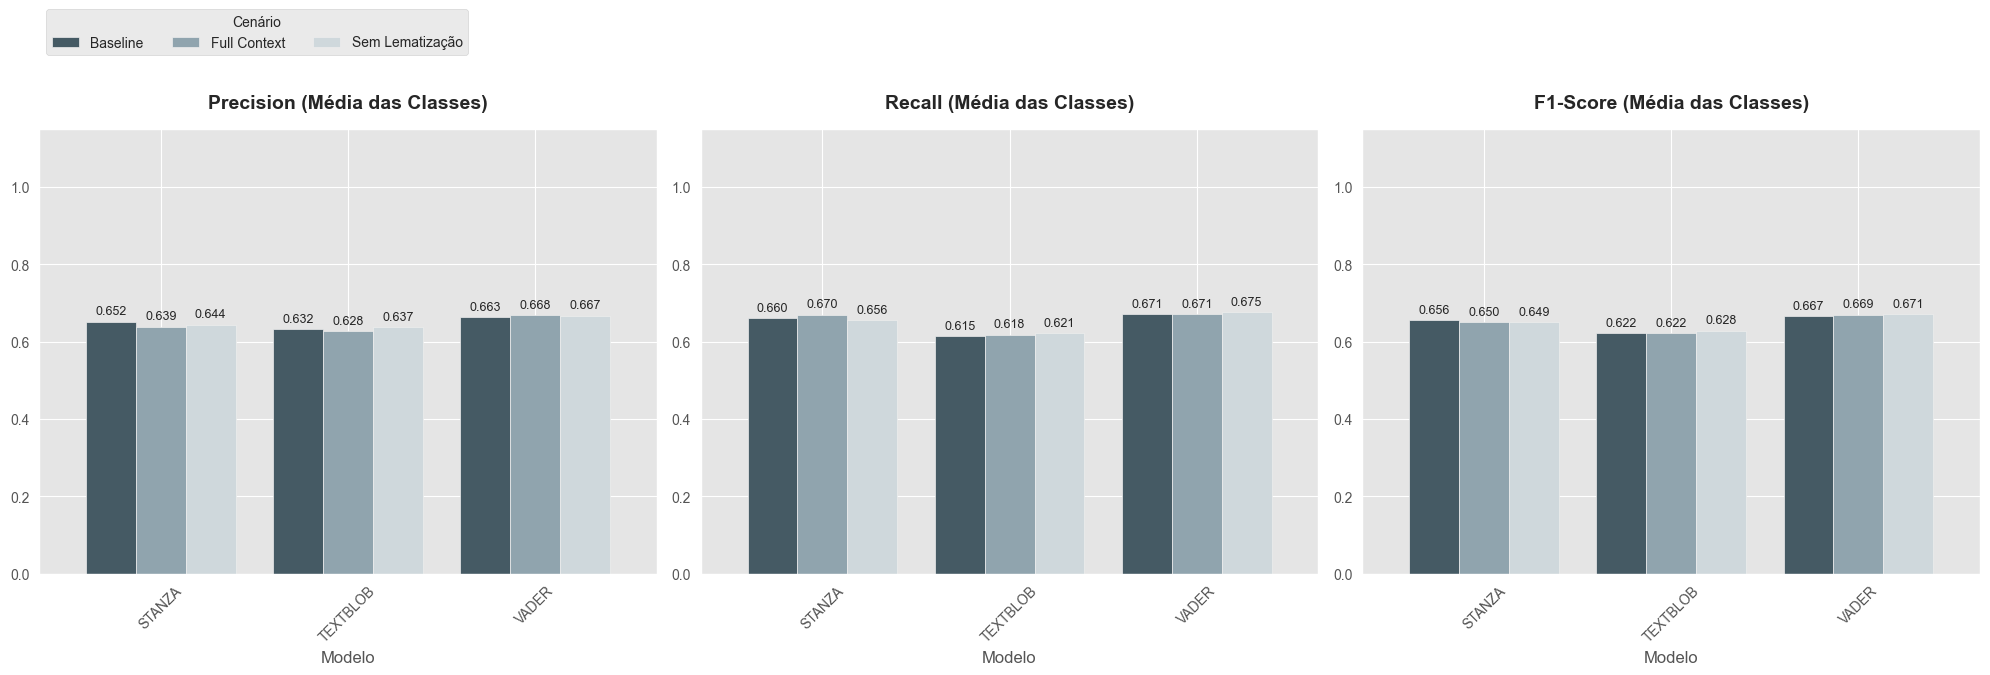

In [29]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
metricas = ["Precision", "Recall", "F1-Score"]
cores_neutras = ["#455A64", "#90A4AE", "#CFD8DC"]

for idx, metrica in enumerate(metricas):
    ax = axes[idx]

    # Substituímos .pivot por .pivot_table para lidar com os duplicados (pos/neg)
    pivot = df_res.pivot_table(index="Modelo", columns="Cenário", values=metrica, aggfunc='mean')

    pivot.plot(kind="bar", ax=ax, color=cores_neutras, width=0.8)

    ax.set_title(f"{metrica} (Média das Classes)", fontsize=14, pad=15, fontweight="bold")
    ax.set_ylim([0, 1.15])
    ax.tick_params(axis="x", rotation=45)

    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9)

    if idx == 0:
        ax.legend(title="Cenário", bbox_to_anchor=(0, 1.15), loc="lower left", ncol=3)
    else:
        ax.legend().remove()

plt.tight_layout()
plt.show()

In [30]:
# Melhor modelo por cenário
print("Melhores modelos por F1-Score:\n")
for cenario_nome in nomes_cenarios.values():
    melhor = df_res[df_res['Cenário'] == cenario_nome].nlargest(1, 'F1-Score')
    print(f"{cenario_nome}: {melhor['Modelo'].values[0]} - F1={melhor['F1-Score'].values[0]:.4f}")


Melhores modelos por F1-Score:

Baseline: VADER - F1=0.8906
Full Context: VADER - F1=0.8936
Sem Lematização: VADER - F1=0.8917


## MATRIZES DE CONFUSÃO

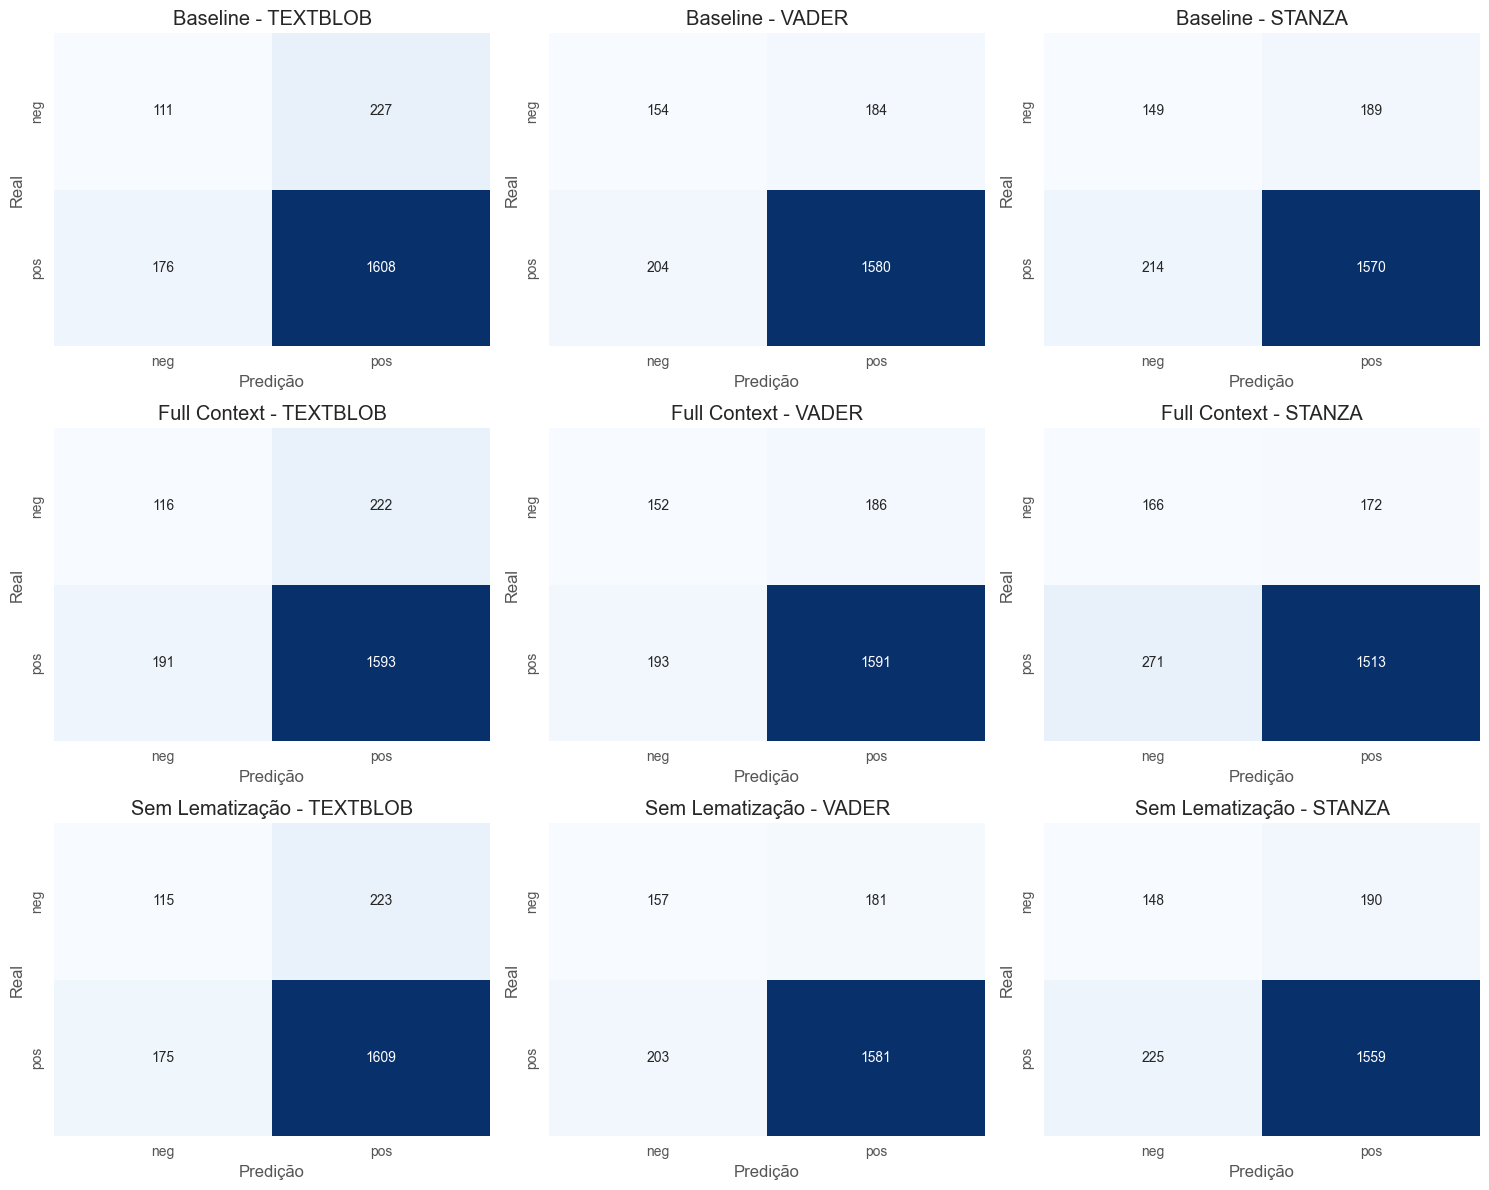

In [31]:
fig, axes = plt.subplots(len(cenarios), len(modelos), figsize=(15, 12))

for i, cenario in enumerate(cenarios):
    for j, modelo in enumerate(modelos):
        col_pred = f'{cenario}_pred_{modelo}'
        cm = confusion_matrix(df_test['class'], df_test[col_pred], labels=['neg', 'pos'])

        ax = axes[i, j]

        sns.heatmap(
            cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            cbar=False,
            xticklabels=['neg', 'pos'],
            yticklabels=['neg', 'pos'],
            ax=ax
        )

        ax.set_title(f"{nomes_cenarios[cenario]} - {modelo.upper()}")
        ax.set_xlabel("Predição")
        ax.set_ylabel("Real")

plt.tight_layout()
plt.savefig('matrizes_confusao_grid.png', dpi=300)
plt.show()

In [32]:
# Guardar resultados
df_res.to_csv('resultados_modelos_lexicos.csv', index=False)
df_test.to_csv('df_test_com_predicoes.csv', index=False)


In [33]:
# Releitura rápida dos resultados

df_resultados = pd.read_csv('resultados_modelos_lexicos.csv')
df_test = pd.read_csv('df_test_com_predicoes.csv')

## Transformers

In [34]:
from transformers import pipeline
import torch

In [35]:
def limpar_para_transformers(text):
    if not isinstance(text, str) or text.strip() == '':
        return ""

    text = re.sub(r'http\S+|www.\S+', '', text)
    text = re.sub(r'\bUSER\b', '', text)
    text = re.sub(r'\bURL\b', '', text)
    text = re.sub(r'^\s*RT\s+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [36]:
df_test['text_transformers'] = df_test['text'].apply(limpar_para_transformers)
df_train['text_transformers'] = df_train['text'].apply(limpar_para_transformers)

In [37]:
df_test[['text', 'text_transformers']].head(5)

,text,text_transformers
0,lmao i love it.,lmao i love it.
1,"Never been to Australia, but I'll keep that in...","Never been to Australia, but I'll keep that in..."
2,Tired as shit...but what else is new...and don...,Tired as shit...but what else is new...and don...
3,Levi's!,Levi's!
4,"no sweetie, its not love, probably just heart ...","no sweetie, its not love, probably just heart ..."


In [38]:
from transformers import pipeline
import torch
# Inicializar pipeline DistilBERT

distilbert_pipeline = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=0 if torch.cuda.is_available() else -1,
    truncation=True,
    max_length=512
)

def classificar_distilbert(textos, batch_size=32):
    if isinstance(textos, str):
        textos = [textos]
    textos_limpos = []
    for t in textos:
        if isinstance(t, str) and t.strip():
            textos_limpos.append(t)
        else:
            textos_limpos.append("neutral text")
    resultados = []
    for i in range(0, len(textos_limpos), batch_size):
        batch = textos_limpos[i:i + batch_size]
        preds = distilbert_pipeline(batch)
        resultados.extend(preds)
    return ['pos' if r['label'] == 'POSITIVE' else 'neg' for r in resultados]


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 5158.31it/s]


In [39]:
# Aplicar DistilBERT aos dados de teste
df_test['pred_distilbert'] = classificar_distilbert(df_test['text_transformers'].tolist())

In [40]:
# Avaliar resultados
resultado_distilbert = avaliar_modelo(
    df_test['class'],
    df_test['pred_distilbert'],
    'DISTILBERT',
    'Transformers'
)

# Adicionar aos resultados existentes
df_resultados = pd.concat([
    df_resultados,
    pd.DataFrame([resultado_distilbert])
], ignore_index=True)

print("\n Resultados DistilBERT:")
print(df_resultados[df_resultados['Modelo'] == 'DISTILBERT'])


 Resultados DistilBERT:
         Cenário      Modelo Classe  Accuracy  Precision  Recall  F1-Score
18  Transformers  DISTILBERT    NaN  0.638077   0.946397  0.6037  0.737166


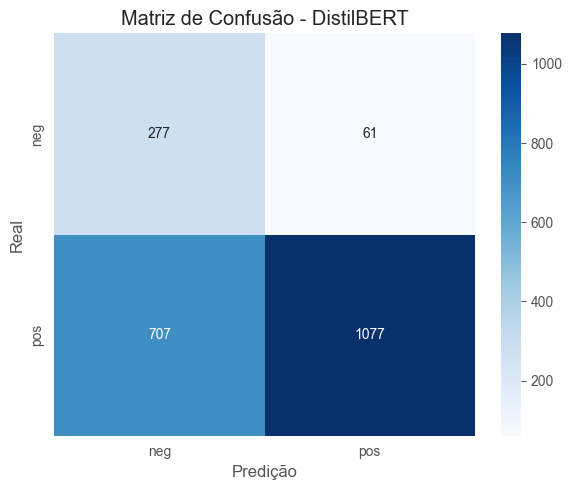


F1-Score DistilBERT: 0.7372
Accuracy: 0.6381


In [41]:
# Matriz de confusão para DistilBERT
cm_distilbert = confusion_matrix(
    df_test['class'],
    df_test['pred_distilbert'],
    labels=['neg', 'pos']
)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_distilbert,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['neg', 'pos'],
    yticklabels=['neg', 'pos'],
    cbar=True
)
plt.title('Matriz de Confusão - DistilBERT')
plt.xlabel('Predição')
plt.ylabel('Real')
plt.tight_layout()
plt.savefig('confusion_matrix_distilbert.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nF1-Score DistilBERT: {resultado_distilbert['F1-Score']:.4f}")
print(f"Accuracy: {resultado_distilbert['Accuracy']:.4f}")

In [42]:
# Verificar textos vazios/problemáticos
print("Textos vazios no teste:")
print(df_test['text'].isna().sum())
print(df_test['text_transformers'].isna().sum())

print("\nTextos que ficaram vazios após limpeza:")
vazios = df_test[df_test['text_transformers'].str.strip() == '']
print(f"Total: {len(vazios)}")
print(vazios[['text', 'text_transformers', 'class']].head(10))

print("\nDistribuição das predições:")
print(df_test['pred_distilbert'].value_counts())

print("\nDistribuição real:")
print(df_test['class'].value_counts())

Textos vazios no teste:
22
0

Textos que ficaram vazios após limpeza:
Total: 26
     text text_transformers class
14    NaN                     pos
57    NaN                     neg
93    NaN                     pos
193  URL                      pos
242   NaN                     neg
448   NaN                     neg
481   NaN                     neg
682   NaN                     pos
695   NaN                     neg
864  URL                      pos

Distribuição das predições:
pred_distilbert
pos    1138
neg     984
Name: count, dtype: int64

Distribuição real:
class
pos    1784
neg     338
Name: count, dtype: int64


In [43]:
# Reclassificar com probabilidades e threshold ajustado
print("Reclassificando com threshold ajustado...")


def classificar_distilbert_ajustado(textos, threshold=0.3, batch_size=32):
    """
    Threshold mais baixo = mais permissivo com 'pos' (bom para datasets desbalanceados)
    threshold=0.3 significa: só classifica 'neg' se prob(neg) > 0.7
    """
    if isinstance(textos, str):
        textos = [textos]

    textos_limpos = []
    for t in textos:
        if isinstance(t, str) and t.strip():
            textos_limpos.append(t)
        else:
            textos_limpos.append("neutral text")

    resultados = []
    for i in range(0, len(textos_limpos), batch_size):
        batch = textos_limpos[i:i + batch_size]
        preds = distilbert_pipeline(batch)
        resultados.extend(preds)

    # Usar score para threshold customizado
    labels = []
    for r in resultados:
        if r['label'] == 'NEGATIVE':
            # Só aceita NEG se tiver alta confiança
            labels.append('neg' if r['score'] > (1 - threshold) else 'pos')
        else:
            # Aceita POS com confiança mais baixa
            labels.append('pos' if r['score'] > threshold else 'neg')

    return labels

Reclassificando com threshold ajustado...


In [44]:
# Testar diferentes thresholds
thresholds = [0.3, 0.4, 0.5]

for thresh in thresholds:
    df_test[f'pred_distilbert_t{int(thresh * 10)}'] = classificar_distilbert_ajustado(
        df_test['text_transformers'].tolist(),
        threshold=thresh
    )

    resultado = avaliar_modelo(
        df_test['class'],
        df_test[f'pred_distilbert_t{int(thresh * 10)}'],
        f'DISTILBERT (threshold={thresh})',
        'Transformers'
    )

    print(f"\nThreshold {thresh}:")
    print(f"F1-Score: {resultado['F1-Score']:.4f}")
    print(f"Accuracy: {resultado['Accuracy']:.4f}")
    print(f"Distribuição: {df_test[f'pred_distilbert_t{int(thresh * 10)}'].value_counts().to_dict()}")


Threshold 0.3:
F1-Score: 0.7482
Accuracy: 0.6489
Distribuição: {'pos': 1175, 'neg': 947}

Threshold 0.4:
F1-Score: 0.7464
Accuracy: 0.6475
Distribuição: {'pos': 1166, 'neg': 956}

Threshold 0.5:
F1-Score: 0.7372
Accuracy: 0.6381
Distribuição: {'pos': 1138, 'neg': 984}


### Leitura do Lexicon e tratamento do mesmo

In [45]:
data_lex = pd.read_csv("../lexicon/NRC-lexicon.csv", encoding="utf-8", index_col=["English"])

lex = (data_lex['Positive'] - data_lex['Negative']).to_dict()

In [46]:
def cobertura_lexico(textos, lexico):
    total = hits = 0
    for t in textos:
        if not isinstance(t, str): continue
        toks   = t.split()
        total += len(toks)
        hits  += sum(1 for w in toks if w in lexico)
    return hits / total * 100 if total else 0

cob = cobertura_lexico(df_test['text_sem_lematizacao'], lex)
print(f'Cobertura do léxico NRC nos tweets: {cob:.1f}%')

Cobertura do léxico NRC nos tweets: 32.5%


### Criação de 4 variantes para processar o léxico:
1. Léxico simples
2. Léxico com negação (inverte sinal)
3. Léxico not
4. Léxico not com tratamento da pontuação anterior

In [47]:
# ── Quatro variantes ──────────────────────────────────────────────────────
def lexico_simples(text):
    if not isinstance(text, str) or not text.strip(): return 'pos'
    score = sum(lex.get(w, 0) for w in text.split())
    return 'pos' if score >= 0 else 'neg'


def lexico_negacao(text):
    score = 0
    if not isinstance(text, str) or text.strip() == "":
        return 'pos'
    tokens = text.split()
    for i, w in enumerate(tokens):
        if w in palavras_negacao and i + 1 < len(tokens):
            prox_palavra = tokens[i + 1]
            score -= lex.get(prox_palavra, 0)
        else:
            score += lex.get(w, 0)
    return 'pos' if score >= 0 else 'neg'


def lexico_not(text):
    if not isinstance(text, str) or not text.strip(): return 'pos'
    tokens, out, neg = text.split(), [], False
    for w in tokens:
        if w in palavras_negacao: neg = True; continue
        if w in {'.','!','?',',',';'}: neg = False; out.append(w); continue
        out.append(f'NOT_{w}' if neg else w)
    score = sum(-lex.get(w[4:], 0) if w.startswith('NOT_') else lex.get(w, 0)
                for w in out)
    return 'pos' if score >= 0 else 'neg'


def prep_not_pont(text):
    if not isinstance(text, str) or not text.strip(): return ''
    text = re.sub(r'http\S+|www\.\S+|\bUSER\b|\bURL\b|@\w+|#', '', text)
    text = re.sub(r'^\s*RT\s+', '', text)
    tokens, out, neg = word_tokenize(text), [], False
    for w in tokens:
        wl = w.lower()
        if wl in palavras_negacao: neg = True; out.append(wl); continue
        if w in {'.','!','?',',',';'}: neg = False; out.append(w); continue
        if re.search(r"[A-Za-z0-9']", w):
            base = lemmatizer.lemmatize(wl)
            out.append(f'NOT_{base}' if neg else base)
    finals = []
    for w in out:
        if w in {'.','!','?',',',';'}: continue
        if w in palavras_negacao or w.startswith('NOT_'):
            finals.append(w); continue
        if w in stopwords_clean: continue
        if re.search(r"[A-Za-z0-9_']", w): finals.append(w)
    return ' '.join(finals)


def lexico_not_pont(text):
    if not isinstance(text, str) or not text.strip(): return 'pos'
    score = sum(-lex.get(w[4:], 0) if w.startswith('NOT_') else lex.get(w, 0)
                for w in text.split())
    return 'pos' if score >= 0 else 'neg'

In [49]:
from sklearn.metrics import classification_report
import pandas as pd

def avaliar_modelo_por_classe(y_true, y_pred, nome_modelo, nome_cenario):
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    res_pos = {
        'Cenário': nome_cenario,
        'Modelo': nome_modelo,
        'Classe': 'pos',
        'Precision': round(report['pos']['precision'], 4),
        'Recall': round(report['pos']['recall'], 4),
        'F1-Score': round(report['pos']['f1-score'], 4)
    }
    res_neg = {
        'Cenário': nome_cenario,
        'Modelo': nome_modelo,
        'Classe': 'neg',
        'Precision': round(report['neg']['precision'], 4),
        'Recall': round(report['neg']['recall'], 4),
        'F1-Score': round(report['neg']['f1-score'], 4)
    }

    return [res_pos, res_neg]

if 'df_res_classes' not in locals():
    df_res_classes = pd.DataFrame()

y_true = df_test['class']


df_test['pred_lex_simples'] = df_test['text_sem_lematizacao'].apply(lexico_simples)
df_test['pred_lex_negacao'] = df_test['text_sem_lematizacao'].apply(lexico_negacao)
df_test['pred_lex_not'] = df_test['text_sem_lematizacao'].apply(lexico_not)

df_test['text_not_pont'] = df_test['text'].apply(prep_not_pont)
df_test['pred_lex_not_pont'] = df_test['text_not_pont'].apply(lexico_not_pont)

for col, nome in [
    ('pred_lex_simples',  'Léxico Simples'),
    ('pred_lex_negacao',  'Léxico com Negação'),
    ('pred_lex_not',      'Léxico NOT_'),
    ('pred_lex_not_pont', 'Léxico NOT_ + Pontuação'),
]:
    novos_resultados = avaliar_modelo_por_classe(y_true, df_test[col], nome, 'Lexicon NRC')
    df_res_classes = pd.concat([df_res_classes, pd.DataFrame(novos_resultados)], ignore_index=True)

df_res_classes = df_res_classes.drop_duplicates(subset=['Modelo', 'Cenário', 'Classe'], keep='last')

print('Resultados NRC por Classe:\n')
tabela_nrc_classes = df_res_classes[df_res_classes['Cenário'] == 'Lexicon NRC'].sort_values(by=['Modelo', 'Classe'])
print(tabela_nrc_classes.to_markdown(index=False))

Resultados NRC por Classe:

| Cenário     | Modelo                  | Classe   |   Precision |   Recall |   F1-Score |
|:------------|:------------------------|:---------|------------:|---------:|-----------:|
| Lexicon NRC | Léxico NOT_             | neg      |      0.3084 |   0.3047 |     0.3065 |
| Lexicon NRC | Léxico NOT_             | pos      |      0.8686 |   0.8705 |     0.8695 |
| Lexicon NRC | Léxico NOT_ + Pontuação | neg      |      0.3263 |   0.3225 |     0.3244 |
| Lexicon NRC | Léxico NOT_ + Pontuação | pos      |      0.8719 |   0.8739 |     0.8729 |
| Lexicon NRC | Léxico Simples          | neg      |      0.325  |   0.3077 |     0.3161 |
| Lexicon NRC | Léxico Simples          | pos      |      0.8701 |   0.8789 |     0.8745 |
| Lexicon NRC | Léxico com Negação      | neg      |      0.329  |   0.3018 |     0.3148 |
| Lexicon NRC | Léxico com Negação      | pos      |      0.8698 |   0.8834 |     0.8765 |


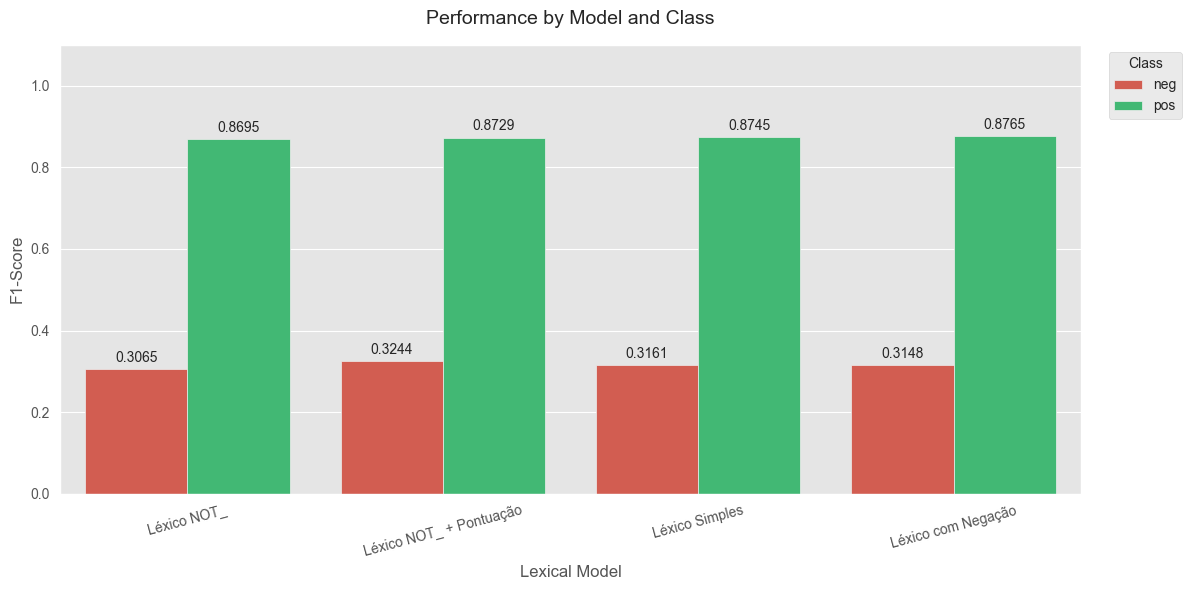

In [50]:
plt.figure(figsize=(12, 6))
class_colors = {'neg': '#e74c3c', 'pos': '#2ecc71'}
ax = sns.barplot(
    data=tabela_nrc_classes,
    x='Modelo',
    y='F1-Score',
    hue='Classe',
    palette=class_colors
)
plt.title('Performance by Model and Class', fontsize=14, pad=15)
plt.xlabel('Lexical Model', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.ylim(0, 1.1)
plt.xticks(rotation=15)

for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=3, fontsize=10)

plt.legend(title='Class', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Treino de Modelos de Aprendizagem Automática

In [51]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

y_train = df_train['class']
y_test = df_test['class']

X_train_tfidf = vectorizer.fit_transform(df_train['text_transformers'])
X_test_tfidf = vectorizer.transform(df_test['text_transformers'])

print("TF-IDF shape (train):", X_train_tfidf.shape)
print("TF-IDF shape (test):", X_test_tfidf.shape)

TF-IDF shape (train): (47799, 10000)
TF-IDF shape (test): (2122, 10000)


In [52]:
vectorizer_char = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3, 5),
    max_features=10000,
    min_df=2,
    sublinear_tf=True
)

X_train_char = vectorizer_char.fit_transform(df_train['text_transformers'])
X_test_char = vectorizer_char.transform(df_test['text_transformers'])

print("Char TF-IDF shape (train):", X_train_char.shape)
print("Char TF-IDF shape (test):", X_test_char.shape)

Char TF-IDF shape (train): (47799, 10000)
Char TF-IDF shape (test): (2122, 10000)


In [53]:

from sklearn.feature_extraction.text import CountVectorizer

vectorizer_bow = CountVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_train_bow = vectorizer_bow.fit_transform(df_train['text_transformers'])
X_test_bow = vectorizer_bow.transform(df_test['text_transformers'])

print("BoW shape (train):", X_train_bow.shape)
print("BoW shape (test):", X_test_bow.shape)

BoW shape (train): (47799, 10000)
BoW shape (test): (2122, 10000)


In [54]:
bnb = BernoulliNB()
bnb.fit(X_train_tfidf, y_train)

bnb_pred = bnb.predict(X_test_tfidf)

print("Bernoulli Naive Bayes Accuracy:", accuracy_score(y_test, bnb_pred))
print("\nBernoulliNB Classification Report:\n", classification_report(y_test, bnb_pred))

Bernoulli Naive Bayes Accuracy: 0.8345900094250707

BernoulliNB Classification Report:
               precision    recall  f1-score   support

         neg       0.48      0.50      0.49       338
         pos       0.91      0.90      0.90      1784

    accuracy                           0.83      2122
   macro avg       0.69      0.70      0.70      2122
weighted avg       0.84      0.83      0.84      2122



In [55]:
bnb_char = BernoulliNB()
bnb_char.fit(X_train_char, y_train)

bnb_char_pred = bnb_char.predict(X_test_char)

print("Bernoulli Naive Bayes (char n-grams) Accuracy:", accuracy_score(y_test, bnb_char_pred))
print("\nBernoulliNB (char n-grams) Classification Report:\n", classification_report(y_test, bnb_char_pred))

Bernoulli Naive Bayes (char n-grams) Accuracy: 0.7615457115928369

BernoulliNB (char n-grams) Classification Report:
               precision    recall  f1-score   support

         neg       0.36      0.65      0.46       338
         pos       0.92      0.78      0.85      1784

    accuracy                           0.76      2122
   macro avg       0.64      0.72      0.66      2122
weighted avg       0.83      0.76      0.79      2122



In [56]:
svm = LinearSVC(max_iter=1000, class_weight='balanced')
svm.fit(X_train_tfidf, y_train)

svm_pred = svm.predict(X_test_tfidf)

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))
print("\nSVM Classification Report:\n", classification_report(y_test, svm_pred))

SVM Accuracy: 0.7836946277097078

SVM Classification Report:
               precision    recall  f1-score   support

         neg       0.39      0.64      0.48       338
         pos       0.92      0.81      0.86      1784

    accuracy                           0.78      2122
   macro avg       0.66      0.72      0.67      2122
weighted avg       0.84      0.78      0.80      2122



In [57]:
svm_char = LinearSVC(class_weight='balanced', max_iter=2000)
svm_char.fit(X_train_char, y_train)

svm_char_pred = svm_char.predict(X_test_char)

print("SVM (char n-grams) Accuracy:", accuracy_score(y_test, svm_char_pred))
print("\nSVM (char n-grams) Classification Report:\n", classification_report(y_test, svm_char_pred))

SVM (char n-grams) Accuracy: 0.7733270499528746

SVM (char n-grams) Classification Report:
               precision    recall  f1-score   support

         neg       0.38      0.64      0.47       338
         pos       0.92      0.80      0.86      1784

    accuracy                           0.77      2122
   macro avg       0.65      0.72      0.66      2122
weighted avg       0.83      0.77      0.79      2122



In [58]:
logreg = LogisticRegression(max_iter=1000, class_weight='balanced')
logreg.fit(X_train_tfidf, y_train)

logreg_pred = logreg.predict(X_test_tfidf)

print("Logistic Regression Accuracy:", accuracy_score(y_test, logreg_pred))
print("\nLogistic Regression Classification Report:\n", classification_report(y_test, logreg_pred))

Logistic Regression Accuracy: 0.7888784165881244

Logistic Regression Classification Report:
               precision    recall  f1-score   support

         neg       0.40      0.69      0.51       338
         pos       0.93      0.81      0.87      1784

    accuracy                           0.79      2122
   macro avg       0.67      0.75      0.69      2122
weighted avg       0.85      0.79      0.81      2122



In [59]:
logreg_char = LogisticRegression(max_iter=1000, class_weight='balanced')
logreg_char.fit(X_train_char, y_train)

logreg_char_pred = logreg_char.predict(X_test_char)

print("Logistic Regression (char n-grams) Accuracy:", accuracy_score(y_test, logreg_char_pred))
print("\nLogistic Regression (char n-grams) Classification Report:\n", classification_report(y_test, logreg_char_pred))

Logistic Regression (char n-grams) Accuracy: 0.7648444863336475

Logistic Regression (char n-grams) Classification Report:
               precision    recall  f1-score   support

         neg       0.37      0.68      0.48       338
         pos       0.93      0.78      0.85      1784

    accuracy                           0.76      2122
   macro avg       0.65      0.73      0.66      2122
weighted avg       0.84      0.76      0.79      2122



In [60]:
logreg_bow = LogisticRegression(max_iter=1000, class_weight='balanced')
logreg_bow.fit(X_train_bow, y_train)

logreg_bow_pred = logreg_bow.predict(X_test_bow)

print("Logistic Regression (BoW) Accuracy:", accuracy_score(y_test, logreg_bow_pred))
print("\nLogistic Regression (BoW) Classification Report:\n", classification_report(y_test, logreg_bow_pred))

Logistic Regression (BoW) Accuracy: 0.8011310084825636

Logistic Regression (BoW) Classification Report:
               precision    recall  f1-score   support

         neg       0.42      0.63      0.50       338
         pos       0.92      0.83      0.88      1784

    accuracy                           0.80      2122
   macro avg       0.67      0.73      0.69      2122
weighted avg       0.84      0.80      0.82      2122



In [61]:
resultado_logreg_bow = avaliar_modelo(
    y_test,
    logreg_bow_pred,
    'Logistic BoW',
    'Bag-of-Words'
)

df_resultados = df_resultados[df_resultados['Modelo'] != 'Logistic BoW']
df_resultados = pd.concat([
    df_resultados,
    pd.DataFrame([resultado_logreg_bow])
], ignore_index=True)

display(df_resultados)

,Cenário,Modelo,Classe,Accuracy,Precision,Recall,F1-Score
0,Baseline,TEXTBLOB,pos,0.810100,0.876300,0.90130,0.888600
1,Baseline,TEXTBLOB,neg,0.810100,0.386800,0.32840,0.355200
2,Baseline,VADER,pos,0.817200,0.895700,0.88570,0.890600
3,Baseline,VADER,neg,0.817200,0.430200,0.45560,0.442500
4,Baseline,STANZA,pos,0.810100,0.892600,0.88000,0.886300
5,Baseline,STANZA,neg,0.810100,0.410500,0.44080,0.425100
6,Full Context,TEXTBLOB,pos,0.805400,0.877700,0.89290,0.885200
7,Full Context,TEXTBLOB,neg,0.805400,0.377900,0.34320,0.359700
8,Full Context,VADER,pos,0.821400,0.895300,0.89180,0.893600
9,Full Context,VADER,neg,0.821400,0.440600,0.44970,0.445100


## Embeddings contextuais

In [62]:
## 2.3.2 Fine-tuning - RoBERTa-base

## 2.3.2 Fine-tuning - RoBERTa-base

In [75]:
from huggingface_hub import login

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    DataCollatorWithPadding
)
from transformers.utils.notebook import NotebookProgressCallback
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_fscore_support, classification_report, confusion_matrix
from torch.nn import CrossEntropyLoss
import torch

In [76]:
df_ft = df_train[['text_transformers', 'class']].copy()
df_ft = df_ft.dropna(subset=['text_transformers', 'class'])
df_ft = df_ft[df_ft['text_transformers'].str.strip() != ''].reset_index(drop=True)

df_test_ft = df_test[['text_transformers', 'class']].copy()
df_test_ft = df_test_ft.dropna(subset=['text_transformers', 'class'])
df_test_ft = df_test_ft[df_test_ft['text_transformers'].str.strip() != '']

label2id = {'neg': 0, 'pos': 1}
id2label = {0: 'neg', 1: 'pos'}

df_ft['label'] = df_ft['class'].map(label2id)
df_test_ft['label'] = df_test_ft['class'].map(label2id)

train_texts, val_texts, train_labels, val_labels = train_test_split(
    df_ft['text_transformers'],
    df_ft['label'],
    test_size=0.2,
    random_state=42,
    stratify=df_ft['label']
)

train_ds = Dataset.from_dict({
    'text': train_texts.tolist(),
    'label': train_labels.tolist()
})

val_ds = Dataset.from_dict({
    'text': val_texts.tolist(),
    'label': val_labels.tolist()
})

test_ds = Dataset.from_dict({
    'text': df_test_ft['text_transformers'].tolist(),
    'label': df_test_ft['label'].tolist()
})

In [77]:
neg_count = int((train_labels == 0).sum())
pos_count = int((train_labels == 1).sum())
total_train = len(train_labels)

weight_neg = total_train / (2 * neg_count)
weight_pos = total_train / (2 * pos_count)

class_weights = torch.tensor([weight_neg, weight_pos], dtype=torch.float)

print("Distribuição no treino:")
print(f"neg: {neg_count} | pos: {pos_count}")
print("Pesos:")
print(f"neg: {weight_neg:.4f} | pos: {weight_pos:.4f}")

Distribuição no treino:
neg: 6486 | pos: 31510
Pesos:
neg: 2.9291 | pos: 0.6029


In [78]:
model_name = "roberta-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def tokenize_function(batch):
    return tokenizer(batch['text'], truncation=True)

train_ds = train_ds.map(tokenize_function, batched=True)
val_ds = val_ds.map(tokenize_function, batched=True)
test_ds = test_ds.map(tokenize_function, batched=True)

train_ds = train_ds.remove_columns(['text'])
val_ds = val_ds.remove_columns(['text'])
test_ds = test_ds.remove_columns(['text'])

train_ds.set_format("torch")
val_ds.set_format("torch")
test_ds.set_format("torch")

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
    id2label=id2label,
    label2id=label2id
)


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 2734.42it/s]
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [79]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        labels, preds, average='macro', zero_division=0
    )

    precision_pos, recall_pos, f1_pos, _ = precision_recall_fscore_support(
        labels, preds, average='binary', pos_label=1, zero_division=0
    )

    acc = (preds == labels).mean()

    return {
        'accuracy': acc,
        'f1_macro': f1_macro,
        'precision_macro': precision_macro,
        'recall_macro': recall_macro,
        'f1_pos': f1_pos,
        'precision_pos': precision_pos,
        'recall_pos': recall_pos
    }


class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        loss_fct = CrossEntropyLoss(weight=class_weights.to(model.device))
        loss = loss_fct(logits.view(-1, model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss


batch_size = 8 if torch.cuda.is_available() else 4

training_args = TrainingArguments(
    output_dir="./roberta_weighted",
    eval_strategy="steps",
    eval_steps=500,
    save_strategy="steps",
    save_steps=500,
    logging_steps=100,
    learning_rate=2e-5,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    num_train_epochs=3,
    weight_decay=0.01,
    warmup_steps=500,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    dataloader_pin_memory=False,
    save_total_limit=2,
    report_to="none",
    disable_tqdm=True,
    seed=42
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

trainer.remove_callback(NotebookProgressCallback)

In [83]:
trainer.train()

{'loss': '0.6835', 'grad_norm': '7.822', 'learning_rate': '3.96e-06', 'epoch': '0.01053'}
{'loss': '0.6713', 'grad_norm': '5.491', 'learning_rate': '7.96e-06', 'epoch': '0.02105'}
{'loss': '0.9579', 'grad_norm': '5.396', 'learning_rate': '1.196e-05', 'epoch': '0.03158'}
{'loss': '0.8774', 'grad_norm': '27.48', 'learning_rate': '1.596e-05', 'epoch': '0.04211'}
{'loss': '0.8622', 'grad_norm': '24.46', 'learning_rate': '1.996e-05', 'epoch': '0.05264'}
{'eval_loss': '1.021', 'eval_accuracy': '0.8617', 'eval_f1_macro': '0.7144', 'eval_precision_macro': '0.7673', 'eval_recall_macro': '0.6865', 'eval_f1_pos': '0.9195', 'eval_precision_pos': '0.8887', 'eval_recall_pos': '0.9525', 'eval_runtime': '453.9', 'eval_samples_per_second': '20.93', 'eval_steps_per_second': '5.233', 'epoch': '0.05264'}


Writing model shards: 100%|██████████| 1/1 [00:03<00:00,  3.24s/it]


{'loss': '0.767', 'grad_norm': '28.73', 'learning_rate': '1.993e-05', 'epoch': '0.06316'}
{'loss': '1.057', 'grad_norm': '17.68', 'learning_rate': '1.986e-05', 'epoch': '0.07369'}
{'loss': '1.049', 'grad_norm': '0.569', 'learning_rate': '1.979e-05', 'epoch': '0.08422'}
{'loss': '0.8554', 'grad_norm': '68.83', 'learning_rate': '1.971e-05', 'epoch': '0.09475'}
{'loss': '0.9529', 'grad_norm': '21.6', 'learning_rate': '1.964e-05', 'epoch': '0.1053'}
{'eval_loss': '0.6918', 'eval_accuracy': '0.8747', 'eval_f1_macro': '0.7438', 'eval_precision_macro': '0.7982', 'eval_recall_macro': '0.7132', 'eval_f1_pos': '0.927', 'eval_precision_pos': '0.8974', 'eval_recall_pos': '0.9585', 'eval_runtime': '400', 'eval_samples_per_second': '23.75', 'eval_steps_per_second': '5.938', 'epoch': '0.1053'}


Writing model shards: 100%|██████████| 1/1 [00:02<00:00,  2.72s/it]


{'loss': '0.6397', 'grad_norm': '0.1221', 'learning_rate': '1.957e-05', 'epoch': '0.1158'}
{'loss': '0.7637', 'grad_norm': '0.1885', 'learning_rate': '1.95e-05', 'epoch': '0.1263'}
{'loss': '0.9433', 'grad_norm': '28.76', 'learning_rate': '1.943e-05', 'epoch': '0.1369'}
{'loss': '0.9656', 'grad_norm': '15.87', 'learning_rate': '1.936e-05', 'epoch': '0.1474'}
{'loss': '0.7014', 'grad_norm': '0.07198', 'learning_rate': '1.929e-05', 'epoch': '0.1579'}
{'eval_loss': '1.185', 'eval_accuracy': '0.8754', 'eval_f1_macro': '0.7277', 'eval_precision_macro': '0.8183', 'eval_recall_macro': '0.6894', 'eval_f1_pos': '0.9282', 'eval_precision_pos': '0.8884', 'eval_recall_pos': '0.9718', 'eval_runtime': '335.2', 'eval_samples_per_second': '28.34', 'eval_steps_per_second': '7.085', 'epoch': '0.1579'}


...

{'loss': '0.8661', 'grad_norm': '0.133', 'learning_rate': '1.743e-05', 'epoch': '0.4316'}
{'loss': '0.7825', 'grad_norm': '15.9', 'learning_rate': '1.736e-05', 'epoch': '0.4422'}
{'loss': '0.9052', 'grad_norm': '22.56', 'learning_rate': '1.729e-05', 'epoch': '0.4527'}
{'loss': '0.7515', 'grad_norm': '0.5982', 'learning_rate': '1.721e-05', 'epoch': '0.4632'}
{'loss': '0.842', 'grad_norm': '1.626', 'learning_rate': '1.714e-05', 'epoch': '0.4737'}
{'eval_loss': '0.729', 'eval_accuracy': '0.8717', 'eval_f1_macro': '0.6933', 'eval_precision_macro': '0.8469', 'eval_recall_macro': '0.6524', 'eval_f1_pos': '0.9272', 'eval_precision_pos': '0.8755', 'eval_recall_pos': '0.9854', 'eval_runtime': '465.3', 'eval_samples_per_second': '20.42', 'eval_steps_per_second': '5.104', 'epoch': '0.4737'}


Writing model shards: 100%|██████████| 1/1 [00:02<00:00,  2.14s/it]


{'train_runtime': '8133', 'train_samples_per_second': '14.02', 'train_steps_per_second': '3.504', 'train_loss': '0.8432', 'epoch': '0.4737'}


There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=4500, training_loss=0.8432417950100369, metrics={'train_runtime': 8132.6988, 'train_samples_per_second': 14.016, 'train_steps_per_second': 3.504, 'train_loss': 0.8432417950100369, 'epoch': 0.47373407727129174})

In [84]:
val_metrics = trainer.evaluate(val_ds)
print("Resultados na validação:")
print(val_metrics)

test_metrics = trainer.evaluate(test_ds)
print("Resultados no teste:")
print(test_metrics)

{'eval_loss': '0.735', 'eval_accuracy': '0.8709', 'eval_f1_macro': '0.7701', 'eval_precision_macro': '0.7726', 'eval_recall_macro': '0.7677', 'eval_f1_pos': '0.9224', 'eval_precision_pos': '0.9203', 'eval_recall_pos': '0.9245', 'eval_runtime': '401.1', 'eval_samples_per_second': '23.69', 'eval_steps_per_second': '5.921', 'epoch': '0.4737'}
Resultados na validação:
{'eval_loss': 0.7349923849105835, 'eval_accuracy': 0.8709473684210526, 'eval_f1_macro': 0.7700980893763565, 'eval_precision_macro': 0.7725551252254294, 'eval_recall_macro': 0.7677236612971741, 'eval_f1_pos': 0.9223657548125633, 'eval_precision_pos': 0.9202678797068486, 'eval_recall_pos': 0.9244732165524244, 'eval_runtime': 401.0871, 'eval_samples_per_second': 23.686, 'eval_steps_per_second': 5.921, 'epoch': 0.47373407727129174}
{'eval_loss': '0.7024', 'eval_accuracy': '0.8693', 'eval_f1_macro': '0.7601', 'eval_precision_macro': '0.7536', 'eval_recall_macro': '0.7672', 'eval_f1_pos': '0.9219', 'eval_precision_pos': '0.9278', '

In [85]:
pred_output = trainer.predict(test_ds)
pred_labels = np.argmax(pred_output.predictions, axis=1)

df_test_ft['pred_roberta_weighted'] = pd.Series(pred_labels, index=df_test_ft.index).map(id2label)

print("\nClassification Report - RoBERTa-base com Class Weights:\n")
print(classification_report(
    df_test_ft['class'],
    df_test_ft['pred_roberta_weighted'],
    digits=4,
    zero_division=0
))


Classification Report - RoBERTa-base com Class Weights:

              precision    recall  f1-score   support

         neg     0.5795    0.6182    0.5982       330
         pos     0.9278    0.9162    0.9219      1766

    accuracy                         0.8693      2096
   macro avg     0.7536    0.7672    0.7601      2096
weighted avg     0.8729    0.8693    0.8710      2096



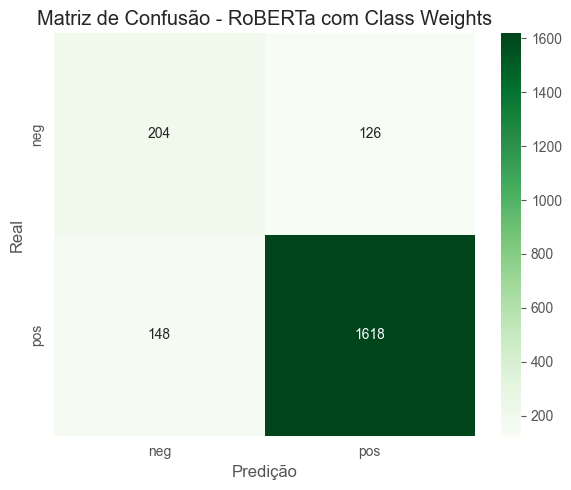

In [86]:
cm_roberta_weighted = confusion_matrix(
    df_test_ft['class'],
    df_test_ft['pred_roberta_weighted'],
    labels=['neg', 'pos']
)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_roberta_weighted,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['neg', 'pos'],
    yticklabels=['neg', 'pos'],
    cbar=True
)
plt.title('Matriz de Confusão - RoBERTa com Class Weights')
plt.xlabel('Predição')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

In [88]:
df_test.loc[df_test_ft.index, 'pred_roberta_weighted'] = df_test_ft['pred_roberta_weighted']

resultado_roberta_weighted = {
    'Cenário': 'Transformers',
    'Modelo': 'ROBERTA Weighted',
    'Accuracy': round(test_metrics['eval_accuracy'], 4),
    'Precision': round(test_metrics['eval_precision_macro'], 4),
    'Recall': round(test_metrics['eval_recall_macro'], 4),
    'F1-Score': round(test_metrics['eval_f1_macro'], 4)
}

if 'df_resultados' in locals():
    df_resultados = df_resultados[df_resultados['Modelo'] != 'ROBERTA Weighted']
    df_resultados = pd.concat([df_resultados, pd.DataFrame([resultado_roberta_weighted])], ignore_index=True)
    display(df_resultados[df_resultados['Modelo'] == 'ROBERTA Weighted'])
else:
    df_resultados = pd.DataFrame([resultado_roberta_weighted])
    display(df_resultados)

print("\nResumo final - RoBERTa-base com Class Weights")
print(f"Accuracy:  {resultado_roberta_weighted['Accuracy']:.4f}")
print(f"Precision: {resultado_roberta_weighted['Precision']:.4f}")
print(f"Recall:    {resultado_roberta_weighted['Recall']:.4f}")
print(f"F1-Score:  {resultado_roberta_weighted['F1-Score']:.4f}")

,Cenário,Modelo,Classe,Accuracy,Precision,Recall,F1-Score
21,Transformers,ROBERTA Weighted,NaN,0.8693,0.7536,0.7672,0.7601



Resumo final - RoBERTa-base com Class Weights
Accuracy:  0.8693
Precision: 0.7536
Recall:    0.7672
F1-Score:  0.7601


## Modelos Baseados em Instruções

In [90]:
from groq import Groq
import time

GROQ_API_KEY = ""
client = Groq(api_key="")

df_llm = df_test[['text', 'class']].copy()
df_llm = df_llm.dropna(subset=['text', 'class'])
df_llm = df_llm[df_llm['text'].str.strip() != ''].reset_index(drop=True)

df_llm_sample = (
    df_llm.groupby('class', group_keys=False)
    .apply(lambda x: x.sample(min(len(x), 100), random_state=42))
    .reset_index(drop=True)
)

print(f"Total da amostra para LLM: {len(df_llm_sample)}")
print(df_llm_sample['class'].value_counts())

Total da amostra para LLM: 200
class
neg    100
pos    100
Name: count, dtype: int64


C:\Users\ferna\AppData\Local\Temp\ipykernel_21460\545280339.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), 100), random_state=42))


In [91]:
PROMPT_GENERICO = """
You are a sentiment classifier.
Classify the sentiment of the given English tweet using exactly one label:
- pos
- neg

Reply with only one label: pos or neg.
"""

PROMPT_DOMINIO = """
You are a sentiment classifier specialized in English tweets.
Tweets may contain informal language, slang, abbreviations, emphasis, repeated punctuation, and short emotional expressions.
Classify the sentiment of the given tweet using exactly one label:
- pos
- neg

Reply with only one label: pos or neg.
"""

PROMPT_EXEMPLOS = """
You are a sentiment classifier specialized in English tweets.

Examples:
Tweet: I love this so much!
Label: pos

Tweet: This is awful, I hate it.
Label: neg

Tweet: Best day ever!!
Label: pos

Tweet: What a terrible experience.
Label: neg

Now classify the next tweet using exactly one label:
- pos
- neg

Reply with only one label: pos or neg.
"""

In [92]:
def classificar_sentimento_llm(texto, system_prompt, tentativas=3, espera=5):
    for tentativa in range(tentativas):
        try:
            response = client.chat.completions.create(
                model="llama-3.3-70b-versatile",
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": f"Tweet: {texto}"}
                ],
                max_tokens=5,
                temperature=0
            )

            resposta = response.choices[0].message.content.strip().lower()

            if resposta == "pos":
                return "pos"
            if resposta == "neg":
                return "neg"

            if "pos" in resposta and "neg" not in resposta:
                return "pos"
            if "neg" in resposta and "pos" not in resposta:
                return "neg"

            return "erro"

        except Exception as e:
            if "429" in str(e):
                print(f"[rate limit] espera {espera}s...")
                time.sleep(espera)
                espera *= 2
            else:
                print(f"[erro] {e}")
                return "erro"

    return "erro"

In [93]:
def avaliar_prompt(df_base, nome_prompt, system_prompt):
    preds = []

    for i, row in df_base.iterrows():
        pred = classificar_sentimento_llm(row['text'], system_prompt)
        preds.append(pred)
        print(f"[{nome_prompt}] {i + 1}/{len(df_base)} -> real={row['class']} | pred={pred}")

    df_out = df_base.copy()
    df_out[f'pred_{nome_prompt}'] = preds

    validos = df_out[df_out[f'pred_{nome_prompt}'].isin(['pos', 'neg'])].copy()

    report = classification_report(
        validos['class'],
        validos[f'pred_{nome_prompt}'],
        output_dict=True,
        zero_division=0
    )

    resultado = {
        'Cenário': 'Instruction-based',
        'Modelo': f'LLAMA ({nome_prompt})',
        'Accuracy': round(report['accuracy'], 4),
        'Precision': round(report['macro avg']['precision'], 4),
        'Recall': round(report['macro avg']['recall'], 4),
        'F1-Score': round(report['macro avg']['f1-score'], 4)
    }

    print(f"\nResultados - {nome_prompt}")
    print(classification_report(
        validos['class'],
        validos[f'pred_{nome_prompt}'],
        digits=4,
        zero_division=0
    ))

    return df_out, validos, resultado

In [94]:
df_llm_generico, validos_generico, resultado_generico = avaliar_prompt(
    df_llm_sample, "generico", PROMPT_GENERICO
)

df_llm_dominio, validos_dominio, resultado_dominio = avaliar_prompt(
    df_llm_sample, "dominio", PROMPT_DOMINIO
)

df_llm_exemplos, validos_exemplos, resultado_exemplos = avaliar_prompt(
    df_llm_sample, "exemplos", PROMPT_EXEMPLOS
)

[generico] 1/200 -> real=neg | pred=pos
[generico] 2/200 -> real=neg | pred=neg
[generico] 3/200 -> real=neg | pred=pos
[generico] 4/200 -> real=neg | pred=pos
[generico] 5/200 -> real=neg | pred=neg
[generico] 6/200 -> real=neg | pred=pos
[generico] 7/200 -> real=neg | pred=neg
[generico] 8/200 -> real=neg | pred=pos
[generico] 9/200 -> real=neg | pred=neg
[generico] 10/200 -> real=neg | pred=neg
[generico] 11/200 -> real=neg | pred=neg
[generico] 12/200 -> real=neg | pred=pos
[generico] 13/200 -> real=neg | pred=neg
[generico] 14/200 -> real=neg | pred=neg
[generico] 15/200 -> real=neg | pred=neg
[generico] 16/200 -> real=neg | pred=neg
[generico] 17/200 -> real=neg | pred=neg
[generico] 18/200 -> real=neg | pred=neg
[generico] 19/200 -> real=neg | pred=pos
[generico] 20/200 -> real=neg | pred=neg
[generico] 21/200 -> real=neg | pred=neg
[generico] 22/200 -> real=neg | pred=neg
[generico] 23/200 -> real=neg | pred=neg
[generico] 24/200 -> real=neg | pred=pos
[generico] 25/200 -> real

In [95]:
df_resultados_llm = pd.DataFrame([
    resultado_generico,
    resultado_dominio,
    resultado_exemplos
])

display(df_resultados_llm.sort_values(by='F1-Score', ascending=False))

,Cenário,Modelo,Accuracy,Precision,Recall,F1-Score
0,Instruction-based,LLAMA (generico),0.770,0.7771,0.770,0.7685
1,Instruction-based,LLAMA (dominio),0.770,0.7771,0.770,0.7685
2,Instruction-based,LLAMA (exemplos),0.755,0.7668,0.755,0.7523


In [96]:
if 'df_resultados' in locals():
    df_resultados = df_resultados[
        ~df_resultados['Modelo'].isin([
            'LLAMA (generico)',
            'LLAMA (dominio)',
            'LLAMA (exemplos)'
        ])
    ]
    df_resultados = pd.concat([df_resultados, df_resultados_llm], ignore_index=True)
else:
    df_resultados = df_resultados_llm.copy()

display(df_resultados[df_resultados['Cenário'] == 'Instruction-based'].sort_values(by='F1-Score', ascending=False))

,Cenário,Modelo,Classe,Accuracy,Precision,Recall,F1-Score
22,Instruction-based,LLAMA (generico),NaN,0.770,0.7771,0.770,0.7685
23,Instruction-based,LLAMA (dominio),NaN,0.770,0.7771,0.770,0.7685
24,Instruction-based,LLAMA (exemplos),NaN,0.755,0.7668,0.755,0.7523


In [97]:
melhor_prompt = df_resultados_llm.sort_values(by='F1-Score', ascending=False).iloc[0]['Modelo']
print(f"Melhor prompt: {melhor_prompt}")

Melhor prompt: LLAMA (generico)


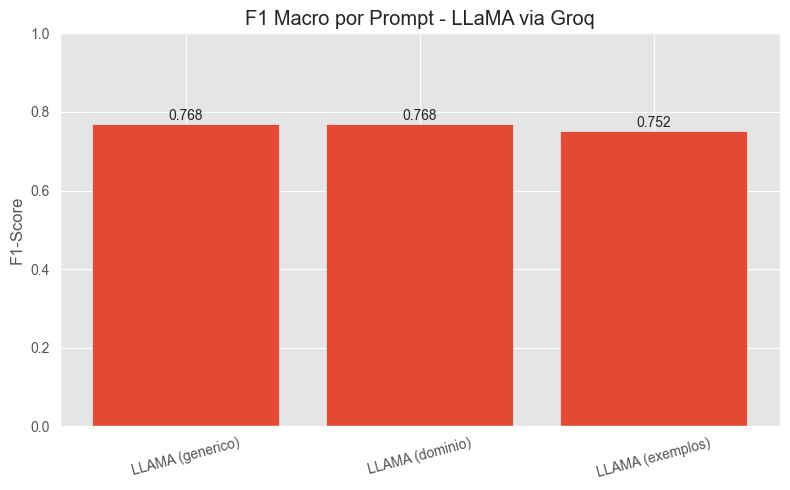

In [98]:
fig, ax = plt.subplots(figsize=(8, 5))

dados_plot = df_resultados_llm.sort_values(by='F1-Score', ascending=False)
bars = ax.bar(dados_plot['Modelo'], dados_plot['F1-Score'])

ax.set_title('F1 Macro por Prompt - LLaMA via Groq')
ax.set_ylabel('F1-Score')
ax.set_ylim(0, 1)

for bar in bars:
    v = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.01, f"{v:.3f}", ha='center')

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

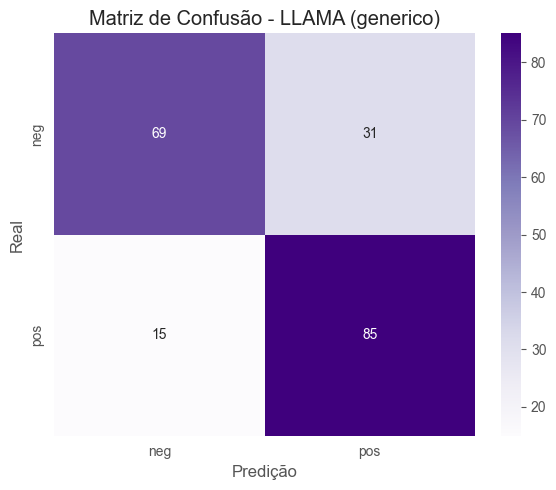

In [99]:
melhor_nome = melhor_prompt.split("(")[1].replace(")", "")

if melhor_nome == "generico":
    validos_melhor = validos_generico
    col_pred = "pred_generico"
elif melhor_nome == "dominio":
    validos_melhor = validos_dominio
    col_pred = "pred_dominio"
else:
    validos_melhor = validos_exemplos
    col_pred = "pred_exemplos"

cm_llm = confusion_matrix(validos_melhor['class'], validos_melhor[col_pred], labels=['neg', 'pos'])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_llm,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=['neg', 'pos'],
    yticklabels=['neg', 'pos'],
    cbar=True
)
plt.title(f'Matriz de Confusão - {melhor_prompt}')
plt.xlabel('Predição')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

In [ ]:
import torch
from torch import nn
from torch.utils.data import Dataset as TorchDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer
)

def avaliar_modelo_por_classe(y_true, y_pred, modelo, cenario):
    """Calcula e separa as métricas para as classes positiva e negativa."""
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)

    resultados = []
    for classe in ['neg', 'pos']:
        if classe in report:
            resultados.append({
                'Cenário': cenario,
                'Modelo': modelo,
                'Classe': classe,
                'Precision': round(report[classe]['precision'], 4),
                'Recall': round(report[classe]['recall'], 4),
                'F1-Score': round(report[classe]['f1-score'], 4),
                'Volume (Nº Tweets)': report[classe]['support']
            })

    return pd.DataFrame(resultados)

class TweetDataset(TorchDataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels    = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

class CustomTrainer(Trainer):
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = torch.tensor(class_weights, dtype=torch.float32).to(self.args.device)

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        loss_fct = nn.CrossEntropyLoss(weight=self.class_weights)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

def treinar_distilbert_finetuned(df_train_completo, df_test, output_dir="./distilbert_finetuned", num_epochs=3, batch_size=16):
    label2id = {"neg": 0, "pos": 1}
    id2label = {0: "neg", 1: "pos"}

    tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

    df_train_sub, df_val = train_test_split(
        df_train_completo,
        test_size=0.2,
        random_state=42,
        stratify=df_train_completo["class"]
    )

    print("Tokenizando dados...")
    train_texts  = df_train_sub["text"].fillna("neutral text").tolist()
    train_labels = [label2id[l] for l in df_train_sub["class"].tolist()]

    val_texts  = df_val["text"].fillna("neutral text").tolist()
    val_labels = [label2id[l] for l in df_val["class"].tolist()]

    test_texts   = df_test["text"].fillna("neutral text").tolist()
    test_labels  = [label2id[l] for l in df_test["class"].tolist()]

    classes_unicas = np.unique(train_labels)
    pesos_calculados = compute_class_weight(
        class_weight='balanced',
        classes=classes_unicas,
        y=train_labels
    )
    print(f"Pesos aplicados [neg, pos]: {pesos_calculados}")

    train_enc = tokenizer(train_texts, truncation=True, padding=True, max_length=128)
    val_enc   = tokenizer(val_texts, truncation=True, padding=True, max_length=128)
    test_enc  = tokenizer(test_texts,  truncation=True, padding=True, max_length=128)

    train_dataset = TweetDataset(train_enc, train_labels)
    val_dataset   = TweetDataset(val_enc, val_labels)
    test_dataset  = TweetDataset(test_enc,  test_labels)

    model = DistilBertForSequenceClassification.from_pretrained(
        "distilbert-base-uncased",
        num_labels=2,
        id2label=id2label,
        label2id=label2id
    )

    training_args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=num_epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size * 2,
        warmup_steps=500,
        weight_decay=0.01,
        logging_steps=100,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        report_to="none"
    )

    trainer = CustomTrainer(
        class_weights=pesos_calculados,
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
    )

    print("A fazer fine-tuning com penalização de classes...")
    trainer.train()

    print("A obter predições finais no conjunto de Teste...")
    preds_output = trainer.predict(test_dataset)
    pred_ids     = np.argmax(preds_output.predictions, axis=1)
    pred_labels  = [id2label[p] for p in pred_ids]

    return pred_labels, model, tokenizer

EXECUTAR_FINETUNING = True

if EXECUTAR_FINETUNING:
    pred_finetuned, modelo_ft, tokenizer_ft = treinar_distilbert_finetuned(
        df_train, df_test, num_epochs=3, batch_size=16
    )
    df_test["pred_distilbert_finetuned"] = pred_finetuned

    df_detalhado = avaliar_modelo_por_classe(
        df_test["class"], df_test["pred_distilbert_finetuned"],
        "DistilBERT (Class Weights)", "Transformers"
    )

    print("\n=== RESULTADOS INDEPENDENTES POR CLASSE ===")
    print(df_detalhado)

else:
    print("Fine-tuning desactivado.")

In [ ]:
def avaliar_modelo_detalhado(y_true, y_pred, modelo, cenario):
    """Calcula as métricas por classe e adiciona uma linha com a visão global (Accuracy)."""
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)

    resultados = []

    for classe in ['neg', 'pos']:
        if classe in report:
            resultados.append({
                'Cenário': cenario,
                'Modelo': modelo,
                'Nível de Análise': f'Classe: {classe}',
                'Accuracy': '-',
                'Precision': round(report[classe]['precision'], 4),
                'Recall': round(report[classe]['recall'], 4),
                'F1-Score': round(report[classe]['f1-score'], 4),
                'Volume': report[classe]['support']
            })

    resultados.append({
        'Cenário': cenario,
        'Modelo': modelo,
        'Nível de Análise': 'Global (Macro Avg)',
        'Accuracy': round(report['accuracy'], 4),
        'Precision': round(report['macro avg']['precision'], 4),
        'Recall': round(report['macro avg']['recall'], 4),
        'F1-Score': round(report['macro avg']['f1-score'], 4),
        'Volume': report['macro avg']['support']
    })

    return pd.DataFrame(resultados)

df_detalhado = avaliar_modelo_detalhado(
    df_test["class"],
    df_test["pred_distilbert_finetuned"],
    "DistilBERT (Class Weights)",
    "Transformers"
)

print("\n=== RESULTADOS COMPLETOS (CLASSES + GLOBAIS) ===")
print(df_detalhado)